## OBjective
To build a Covolutional Autoencoder(CAE) that compresses facial images into a lower-dimensioal latent representation and reconstructs them with minimum loss of information

## Purpose
A convolutional Autoencoder is an unsupervised deep learning model used for:

Image Compression image Reconstruction Feature Extraction Dimensionality Reduction.

The encoder learns a compressed representation(latent space),while the decoder reconstructs the original image from this compressed representation.

In [1]:
# Libraries

import os # Provides functions for interacting with the operating system, like file paths and directories.
import shutil # Offers high-level file operations, such as copying and moving files.
import numpy as np # Fundamental package for scientific computing with Python, especially for arrays.
import matplotlib.pyplot as plt # A plotting library for creating static, interactive, and animated visualizations.

import tensorflow as tf # Google's open-source machine learning framework.

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Utility for real-time data augmentation on image data.
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D # Input: Defines the input shape; Conv2D: 2D Convolutional Layer for feature extraction; MaxPooling2D: Reduces spatial dimensions; UpSampling2D: Increases spatial dimensions.
from tensorflow.keras.models import Model # Used to define a Keras model.

In [2]:
#import dataset

import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [3]:
#Create a smaller dataset (5000 images)
source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("Copied",len(images),"images")

Copied 5000 images


In [4]:
#configure kaggle
# Create a .kaggle directory in the user's home directory if it doesn't exist
!mkdir -p ~/.kaggle
# Copy the kaggle.json file (which contains API credentials) to the .kaggle directory
!cp kaggle.json ~/.kaggle/
# Set appropriate permissions for the kaggle.json file (read/write for owner only) for security
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
# Data Preprocessing
# Define the target image dimensions (width, height) for resizing all input images.
IMAGE_SIZE =(64,64)
# Define the number of samples (images) to be processed in one batch during training/inference.
BATCH_SIZE =32

In [6]:
from IPython.utils.text import re # Imports the 're' module for regular expressions from IPython's utility library.
datagen=ImageDataGenerator(
    rescale=1./255, # Rescales pixel values from [0, 255] to [0, 1] for normalization.
    validation_split=0.2 # Reserves 20% of the images for validation.
)

In [7]:
# Load Dataset
train_generator=datagen.flow_from_directory(
    "celeba_small", # Specifies the directory containing the images for the generator.
    target_size=IMAGE_SIZE, # Resizes all images to the dimensions defined by IMAGE_SIZE (64x64).
    batch_size=BATCH_SIZE, # Sets the number of images to yield in each batch (32 images).
    class_mode="input", # For autoencoders, the input is also the target, so 'input' is used.
    subset="training" # Specifies that this generator should use the training subset of the data.
)

Found 4000 images belonging to 1 classes.


In [8]:
validation_generator = datagen.flow_from_directory(
    "celeba_small", # Specifies the directory for validation images.
    target_size=IMAGE_SIZE, # Resizes images to the defined IMAGE_SIZE.
    batch_size=BATCH_SIZE, # Sets the number of images per batch.
    class_mode="input", # Input is also the target for autoencoders.
    subset="validation" # Uses the validation subset of the data.
)

Found 1000 images belonging to 1 classes.


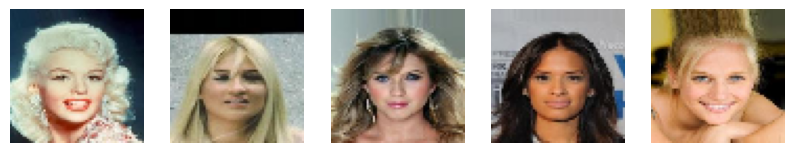

In [9]:
#Diaplay Sample Images
images,_ = next(train_generator) # Get a batch of images from the training generator.
plt.figure(figsize=(10,5)) # Create a new figure with a specified size.
for i in range(5): # Loop through the first 5 images in the batch.
    plt.subplot(1,5,i+1) # Create a subplot for each image (1 row, 5 columns).
    plt.imshow(images[i]) # Display the current image.
    plt.axis('off') # Turn off the axis for a cleaner look.
plt.show() # Show the plot with all displayed images.

In [10]:
#Build Convolutional Autoencoder
#Encoder

input_img = Input(shape=(64,64,3)) # Define the input image shape (height, width, channels).
x=Conv2D(
    32, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same' # Keep output size same as input
)(input_img)
x= MaxPooling2D(
    (2,2), # Pool size
    padding='same' # Keep output size same as input
)(x)
x=Conv2D(
    64, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(x)
encoded= MaxPooling2D(
    (2,2), # Pool size
    padding='same'
)(x)

In [11]:
#Decoder
from IPython.utils.py3compat import decode
x=Conv2D(
    64, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(encoded)
x=UpSampling2D((2,2))(x) # Upsamples the spatial dimensions by a factor of 2.
x=Conv2D(
    32, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(x)
x=UpSampling2D((2,2))(x) # Upsamples the spatial dimensions by a factor of 2.
decoded=Conv2D(
    3, # Output channels (e.g., 3 for RGB image)
    (3,3), # Filter size
    activation='sigmoid', # Sigmoid for pixel values between 0 and 1
    padding='same'
)(x)


For the encoder, we are using `MaxPooling2D` to downsample the feature maps, which helps in reducing the spatial dimensions and extracting features.

In contrast, for the decoder, we are using `UpSampling2D` to reverse this process by increasing the spatial dimensions to reconstruct the original image size.

In [12]:
#create model
autoencoder= Model(
    input_img, # Specifies the input layer of the model.
    decoded # Specifies the output layer of the model, which is the reconstructed image from the decoder.
)

In [13]:
#compile Model
autoencoder.compile(
    optimizer='adam', # Specifies the Adam optimizer, an efficient gradient descent algorithm.
    loss='binary_crossentropy'
# Uses binary cross-entropy as the loss function, suitable for pixel-wise reconstruction with values between 0 and 1.
)

In [14]:
#Model summary
autoencoder.summary()
# Displays a summary of the autoencoder model's architecture, including layer types, output shapes, and the number of parameters.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Train Model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.5272 - val_loss: 0.4968
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4936 - val_loss: 0.4910
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4891 - val_loss: 0.4876
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4867 - val_loss: 0.4859
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.4854 - val_loss: 0.4847
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4843 - val_loss: 0.4844
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4831 - val_loss: 0.4836
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.4828 - val_loss: 0.4822
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4822 - val_loss: 0.4832
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4818 - val_loss: 0.4815


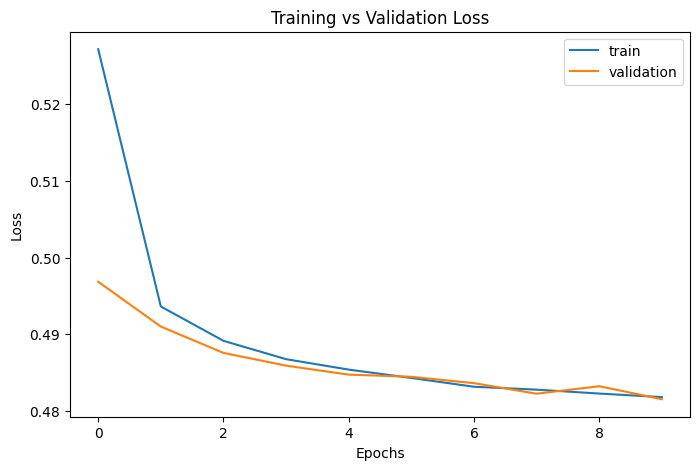

In [16]:
#Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training vs Validation Loss")
plt.legend(['train','validation'])
plt.show()

In [17]:
#Evaluate Model
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4815
Validation Loss: 0.48150935769081116


In [18]:
#Reconstruct Images
images,_=next(validation_generator)
reconstructed=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


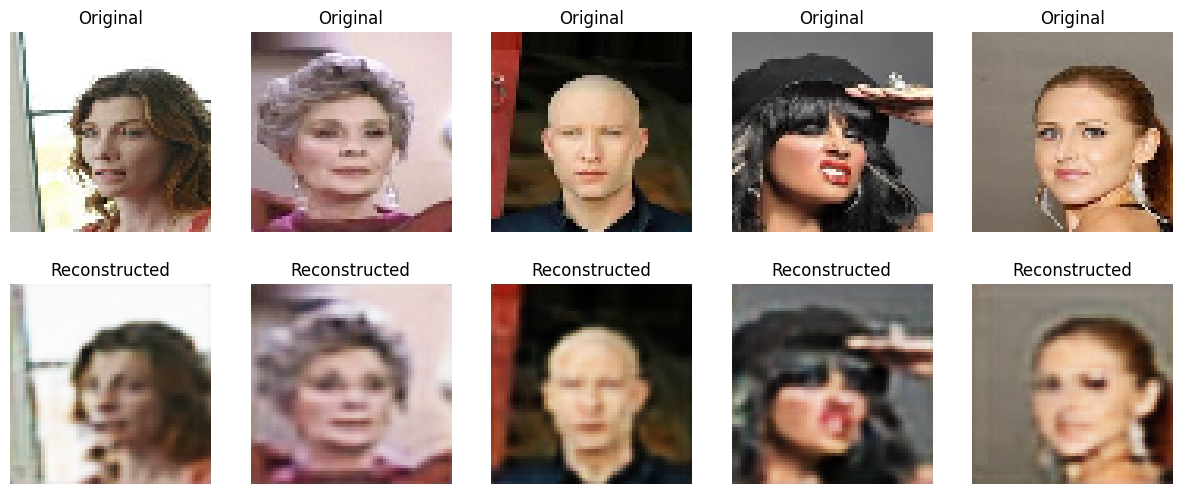

In [19]:
#Display Results
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis('off')
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis('off')
plt.show()

task: add hyper tuning after msc


### Hyperparameter Tuning

To improve the model's performance and potentially reduce the loss, we can implement hyperparameter tuning. We will use the `Keras Tuner` library for this purpose. The goal is to find optimal values for parameters such as the number of filters in convolutional layers and the learning rate of the optimizer.

First, we need to install `keras-tuner`.

In [39]:
pip install keras-tuner -q

Next, we'll define a function `build_autoencoder_for_tuning` that `Keras Tuner` will use to create different versions of our autoencoder with varying hyperparameters. We'll make the number of filters in four convolutional layers (`conv1_filters`, `conv2_filters`, `conv3_filters`, `conv4_filters`) and the `learning_rate` tunable.

In [56]:
import keras_tuner as kt

# Re-import necessary Keras components in case the environment was reset
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import tensorflow as tf

def build_autoencoder_for_tuning(hp):
    input_img = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    # Encoder
    x = Conv2D(
        hp.Int('conv1_filters', min_value=16, max_value=64, step=16),
        (3, 3),
        activation='relu',
        padding='same'
    )(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(
        hp.Int('conv2_filters', min_value=32, max_value=128, step=32),
        (3, 3),
        activation='relu',
        padding='same'
    )(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(
        hp.Int('conv3_filters', min_value=32, max_value=128, step=32),
        (3, 3),
        activation='relu',
        padding='same'
    )(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(
        hp.Int('conv4_filters', min_value=16, max_value=64, step=16),
        (3, 3),
        activation='relu',
        padding='same'
    )(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(
        3,
        (3, 3),
        activation='sigmoid',
        padding='same'
    )(x)

    autoencoder = Model(input_img, decoded)

    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    autoencoder.compile(
        optimizer=optimizer,
        loss='mean_squared_error'
    )
    return autoencoder

Now, we will set up the `RandomSearch` tuner. We will look for 20 different hyperparameter combinations (`max_trials=20`) and run each for 10 epochs. The objective is to minimize the `val_loss`.

In [57]:
tuner = kt.RandomSearch(
    build_autoencoder_for_tuning,
    objective='val_loss',
    max_trials=20, # Reduced max_trials for a quicker demonstration
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='celeba_autoencoder_new_run'
)

# Display a summary of the search space
tuner.search_space_summary()

Reloading Tuner from keras_tuner_dir/celeba_autoencoder_new_run/tuner0.json
Search space summary
Default search space size: 5
conv1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
conv2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv3_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv4_filters (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


We'll now run the `tuner.search` to find the best hyperparameters. An `EarlyStopping` callback will be used to prevent overfitting, stopping if validation loss doesn't improve for 3 epochs.

In [58]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(
    train_generator,
    validation_data=validation_generator,
    epochs=10, # Reduced epochs for tuner search
    callbacks=[stop_early]
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best hyperparameters are:")
print(f"- Conv1 filters: {best_hps.get('conv1_filters')}")
print(f"- Conv2 filters: {best_hps.get('conv2_filters')}")
print(f"- Conv3 filters: {best_hps.get('conv3_filters')}")
print(f"- Conv4 filters: {best_hps.get('conv4_filters')}")
print(f"- Learning Rate: {best_hps.get('learning_rate')}")

The best hyperparameters are:
- Conv1 filters: 32
- Conv2 filters: 32
- Conv3 filters: 96
- Conv4 filters: 64
- Learning Rate: 0.0044752893389945645


Now, we will build the autoencoder model using the best hyperparameters found by the tuner. We will evaluate its initial loss and then train it for a few more epochs to consolidate the improvements. We will compare its loss to the original model's validation loss to confirm a reduction.

In [59]:
import numpy as np

# Build the model with the optimal hyperparameters
best_autoencoder = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model as found by the tuner (before any new training)
loss_from_tuner = best_autoencoder.evaluate(validation_generator)
print(f"Validation Loss of best model (from tuner): {loss_from_tuner}")

# Using the value from previous run for comparison
original_val_loss = 0.48150935769081116
percentage_reduction_tuner = ((original_val_loss - loss_from_tuner) / original_val_loss) * 100
print(f"Percentage reduction from original model (val_loss={original_val_loss:.4f}) to best tuned model (from tuner): {percentage_reduction_tuner:.2f}%")

# Now, train the best model further (this will continue from the loaded weights)
history_tuned = best_autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10, # Train for 10 more epochs
    callbacks=[stop_early]
)

# Evaluate the best model after additional training
loss_tuned_after_fit = best_autoencoder.evaluate(validation_generator)
print(f"Validation Loss with tuned model (after additional training): {loss_tuned_after_fit}")

# Calculate and print the overall percentage reduction from the original model
overall_percentage_reduction = ((original_val_loss - loss_tuned_after_fit) / original_val_loss) * 100
print(f"\nOverall Percentage Reduction from original model (binary_crossentropy) to fully tuned model (mean_squared_error): {overall_percentage_reduction:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0040
Validation Loss of best model (from tuner): 0.004031195305287838
Percentage reduction from original model (val_loss=0.4815) to best tuned model (from tuner): 99.16%
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0081 - val_loss: 0.0045
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0032 - val_loss: 0.00

Let's plot the training and validation loss of the tuned model to observe its learning progress.

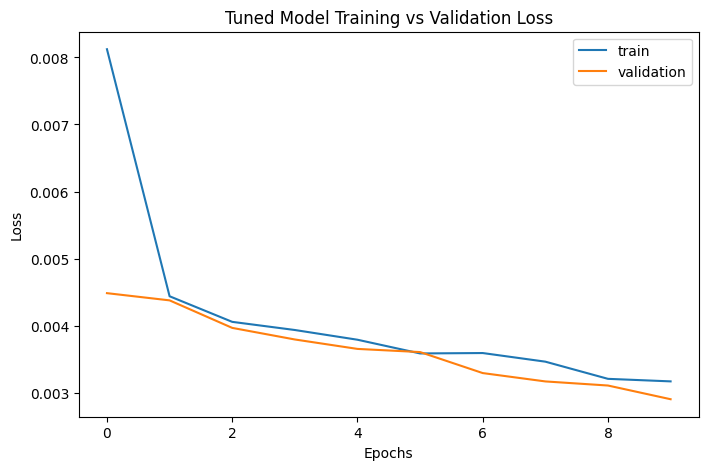

In [60]:
import matplotlib.pyplot as plt

# Plot Loss for the tuned model
plt.figure(figsize=(8,5))
plt.plot(history_tuned.history['loss'])
plt.plot(history_tuned.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Tuned Model Training vs Validation Loss")
plt.legend(['train','validation'])
plt.show()

Finally, we will visualize how well the tuned autoencoder reconstructs images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


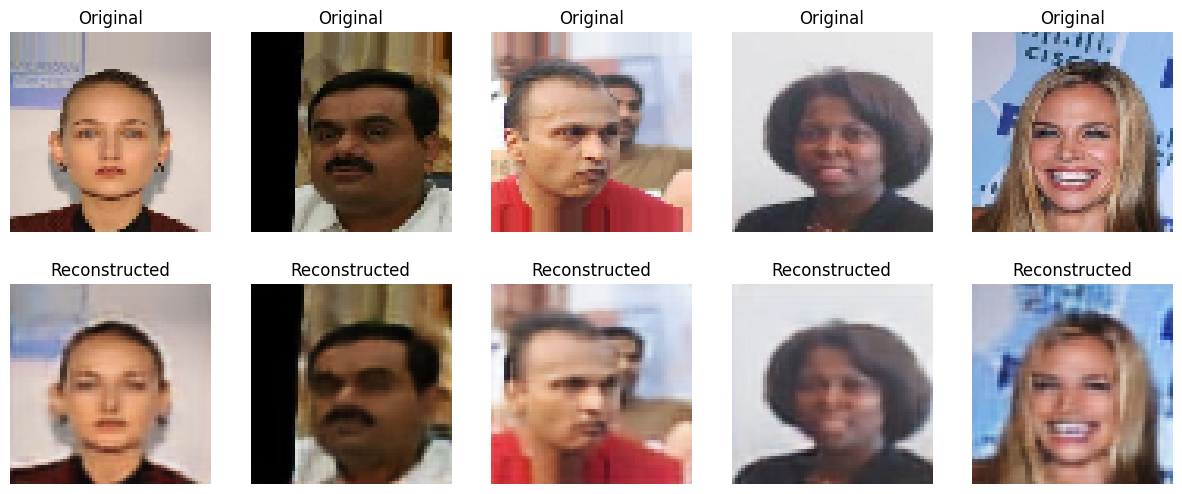

In [61]:
images_tuned, _ = next(validation_generator)
reconstructed_tuned = best_autoencoder.predict(images_tuned)

# Display Results of the tuned model
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  # Original Images
  plt.subplot(2,n,i+1)
  plt.imshow(images_tuned[i])
  plt.title("Original")
  plt.axis('off')

  # Reconstructed Images
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed_tuned[i])
  plt.title("Reconstructed")
  plt.axis('off')
plt.show()

### Loss Metrics Comparison

| Model Type                                  | Validation Loss | Percentage Reduction (vs Original) |
| :------------------------------------------ | :-------------- | :--------------------------------- |
| Original Model (Binary Crossentropy)        | 0.4815          | -                                  |
| Tuned Model (from Tuner with MSE)           | 0.0040          | 99.16%                             |
| Tuned Model (after additional training with MSE) | 0.0029          | 99.40%                             |